In [100]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo 
from matplotlib import pyplot as plt
from scipy.linalg import qr
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as colors
from sklearn.linear_model import RidgeCV


In [4]:
# fetch dataset 
communities_and_crime = fetch_ucirepo(id=183) 
  
# data (as pandas dataframes) 
X = communities_and_crime.data.features
y = communities_and_crime.data.targets
df = pd.concat([X, y], axis=1)
# change ? (missing value indicator) to NAs and drop columns with missing values
df.replace('?', pd.NA, inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')
df_clean = df.dropna(axis=1)
# dropping these categorical columns rather than one-hot encoding them because 
# if we include only some of the one-hot encoded ones that's a bit weird
df_clean.drop(columns=["state", "fold"], inplace=True)
df_clean

/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/147206845.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.drop(columns=["state", "fold"], inplace=True)


,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,ViolentCrimesPerPop
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.12,0.42,0.50,0.51,0.64,0.12,0.26,0.20,0.32,0.20
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,0.21,0.50,0.34,0.60,0.52,0.02,0.12,0.45,0.00,0.67
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,0.14,0.49,0.54,0.67,0.56,0.01,0.21,0.02,0.00,0.43
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,0.19,0.30,0.73,0.64,0.65,0.02,0.39,0.28,0.00,0.12
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,0.11,0.72,0.64,0.61,0.53,0.04,0.09,0.02,0.00,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,0.01,0.40,0.10,0.87,0.12,0.16,0.43,0.51,0.35,0.30,...,0.22,0.28,0.34,0.48,0.39,0.01,0.28,0.05,0.00,0.09
1990,0.05,0.96,0.46,0.28,0.83,0.32,0.69,0.86,0.73,0.14,...,0.53,0.25,0.17,0.10,0.00,0.02,0.37,0.20,0.00,0.45
1991,0.16,0.37,0.25,0.69,0.04,0.25,0.35,0.50,0.31,0.54,...,0.25,0.68,0.61,0.79,0.76,0.08,0.32,0.18,0.91,0.23
1992,0.08,0.51,0.06,0.87,0.22,0.10,0.58,0.74,0.63,0.41,...,0.45,0.64,0.54,0.59,0.52,0.03,0.38,0.33,0.22,0.19


In [93]:
y_clean = df_clean[['ViolentCrimesPerPop']].values
X_clean = df_clean.drop(columns=['ViolentCrimesPerPop']).values
n, m = np.shape(X_clean)
# randomly order the data and the columns
idx = np.random.permutation(n)
X_clean = X_clean[idx]
y_clean = y_clean[idx]
# for random order:
ordering = 0
col_idx = np.random.permutation(m)
X_clean = X_clean[:, col_idx]
# for ordering by weight in theta_full
# ordering = 1
# theta_full = np.linalg.lstsq(X_clean, y_clean, rcond=None)[0]
# col_idx = np.argsort(theta_full.flatten())
# X_clean = X_clean[:, col_idx]

# for ordering by QR decomp of X_clean (M)
# ordering = 2
# _, R, P = qr(X_clean, pivoting=True)
# X_clean = X_clean[:, P]
n_train = 100
X_train = X_clean[:n_train, :]
y_train = y_clean[:n_train]
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = X_clean[n_train:, :]
y_val = y_clean[n_train:]
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)


In [97]:
n_epochs = 300

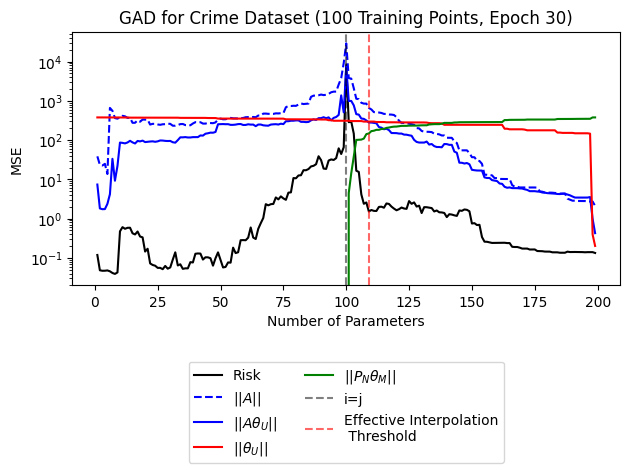

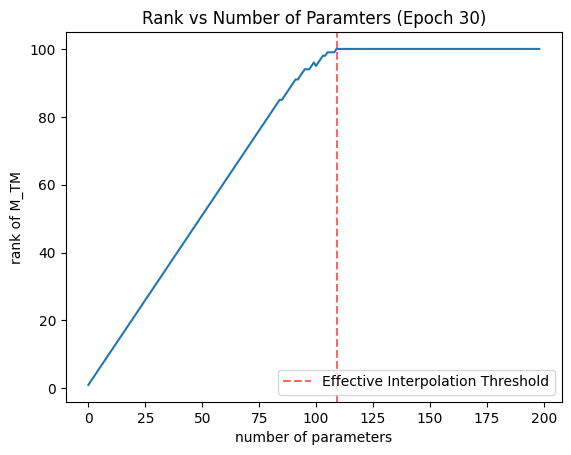

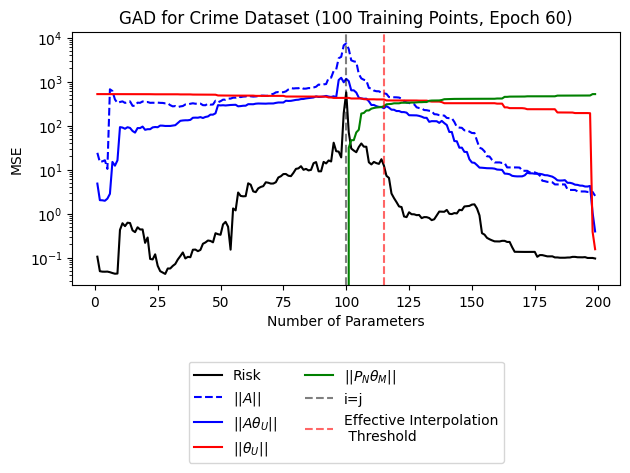

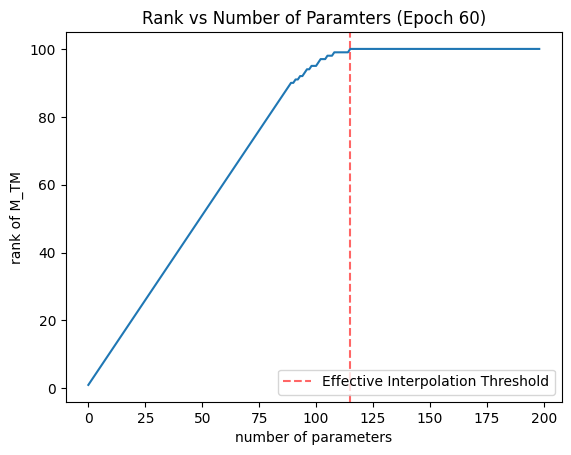

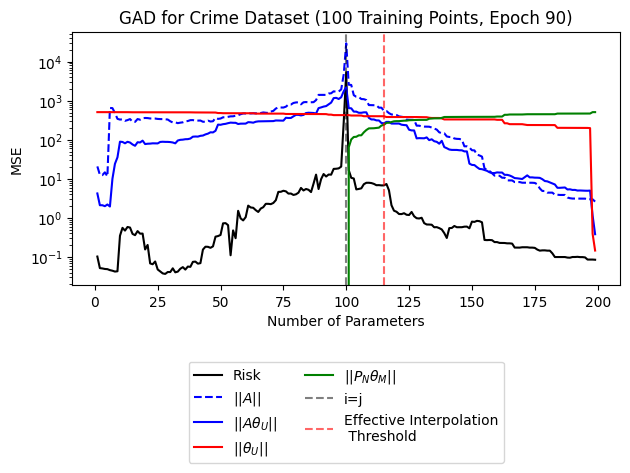

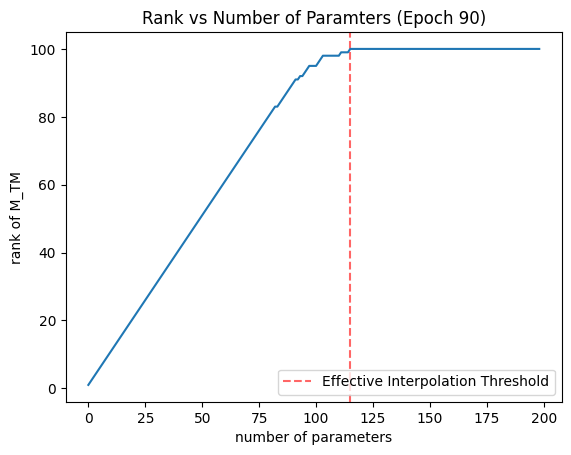

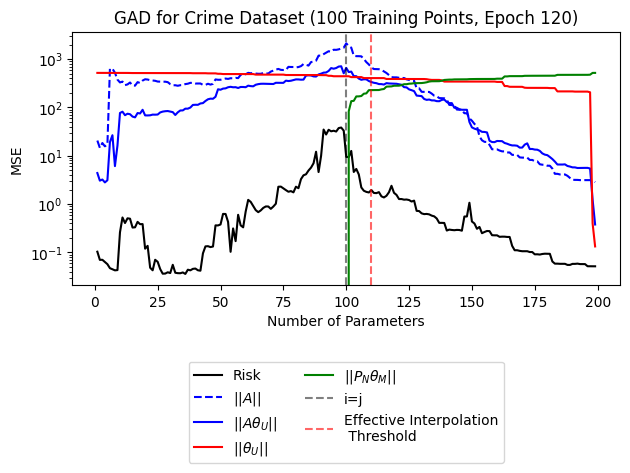

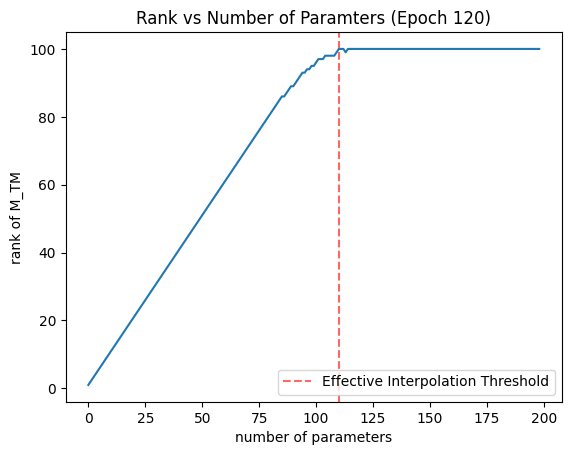

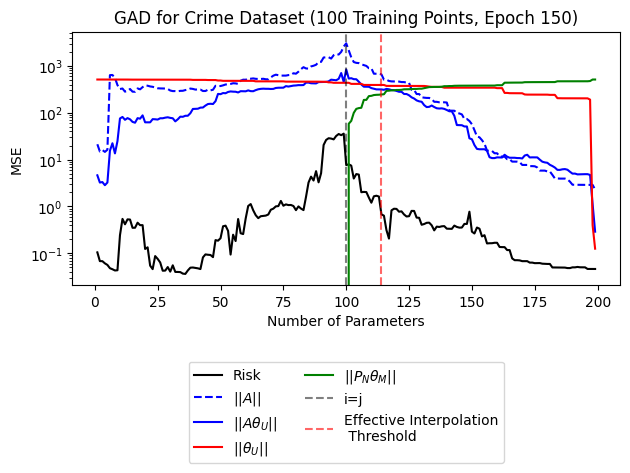

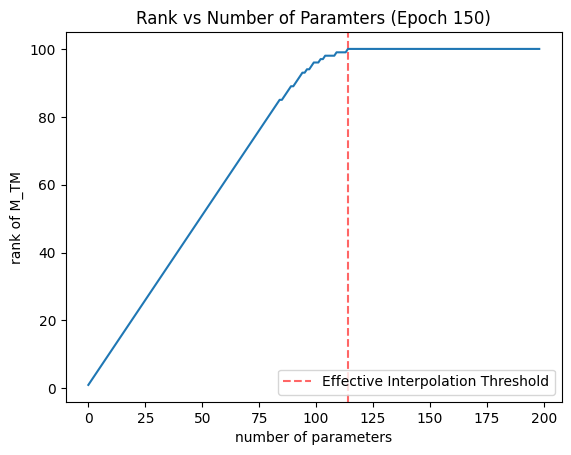

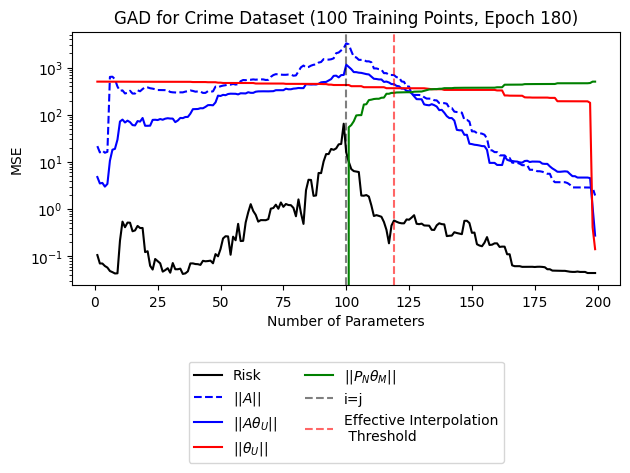

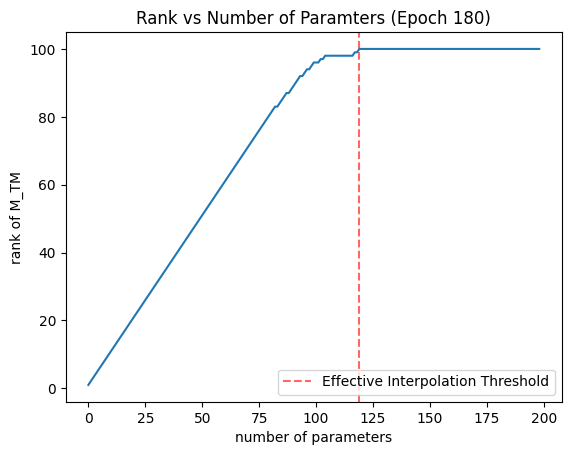

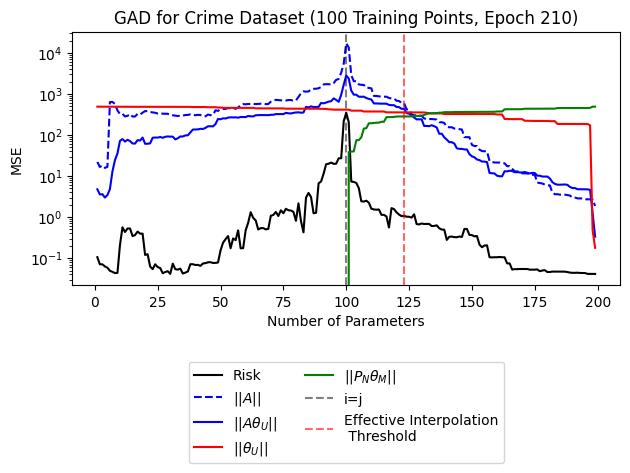

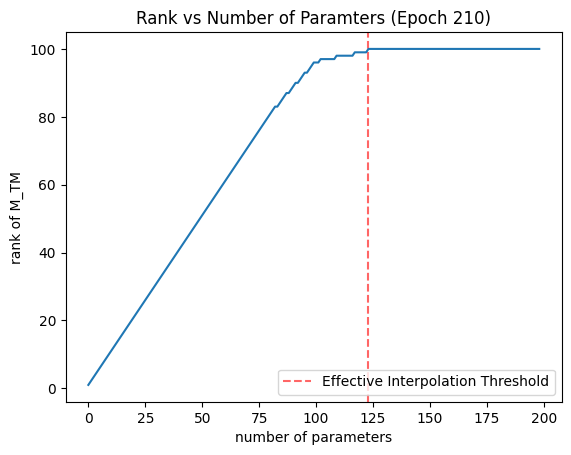

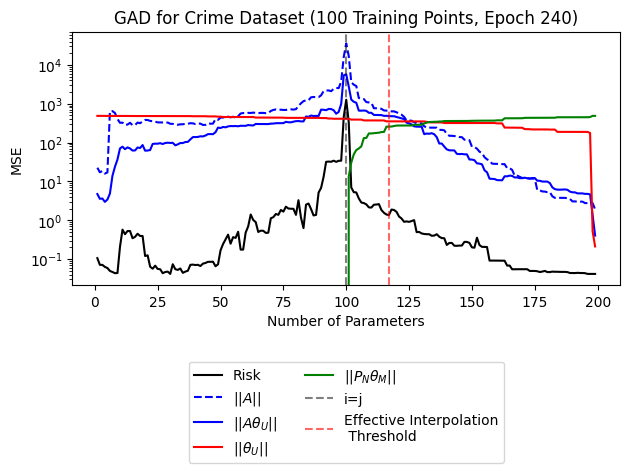

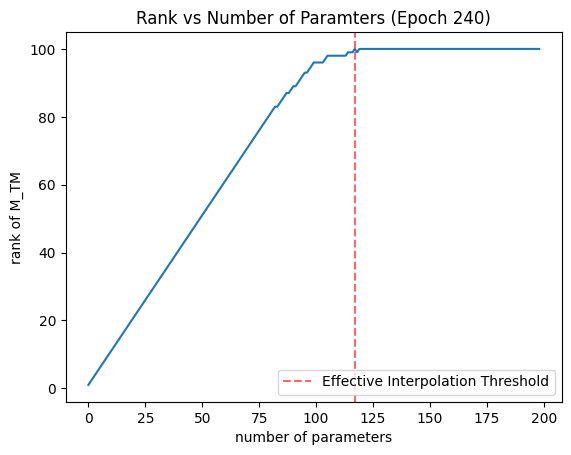

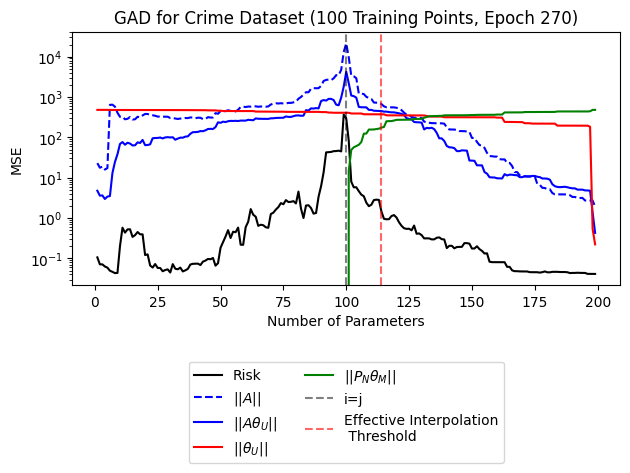

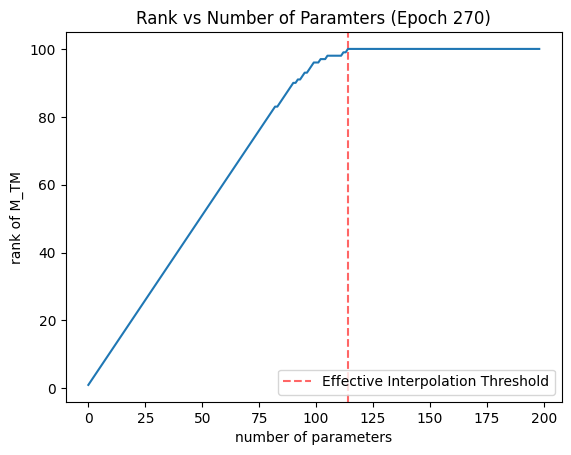

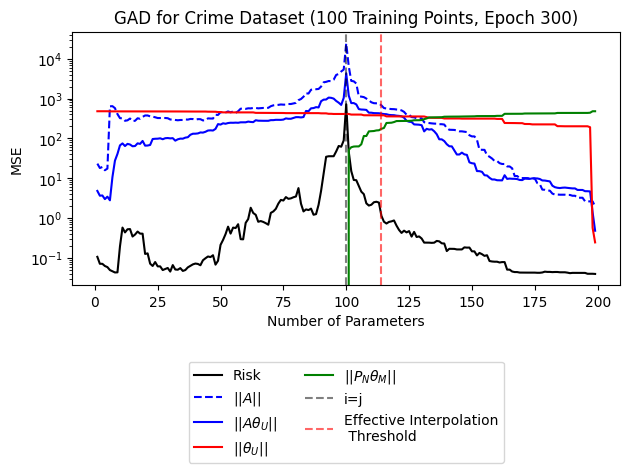

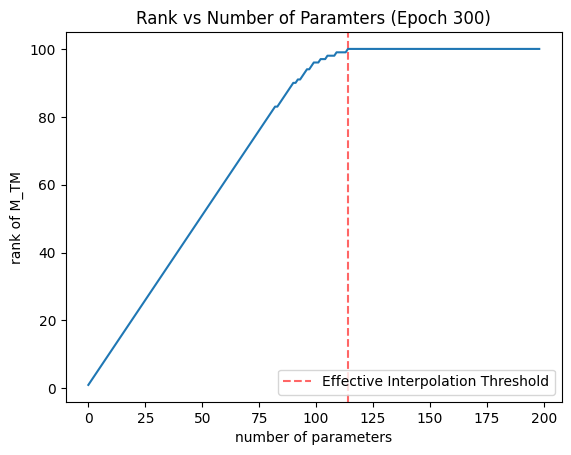

In [107]:
class GADNet(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.hidden = nn.Linear(in_dim, hidden_dim)
        self.act = nn.LeakyReLU()
        self.out = nn.Linear(hidden_dim, 1)

    def features(self, x):
        # this is your Conjugate Kernel feature map at the current weights
        return self.act(self.hidden(x))

    def forward(self, x):
        return self.out(self.features(x))
m = 200

model = GADNet(in_dim=99, hidden_dim=m)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
losses = []
for epoch in range(1, n_epochs + 1):
    optimizer.zero_grad()       # clear old gradients
    preds = model(X_train)      # forward pass
    loss = loss_fn(preds, y_train)
    losses.append(float(loss))
    loss.backward()             # backprop
    optimizer.step()            # update weights
    if epoch % 30 == 0: # checkpoint every 5 epochs
        with torch.no_grad():
            M_train = model.features(X_train).numpy()
            M_val   = model.features(X_val).numpy()
            M = np.vstack((M_train, M_val))
            
        error = np.zeros(m)
        test_error = np.zeros(m)
        norm_A = np.zeros(m)
        norm_PN_theta = np.zeros(m)
        norm_theta_U = np.zeros(m)
        norm_A_theta_u = np.zeros(m - 1)
        norm_pinv_MTM = np.zeros(m - 1)
        first_spectral_val = np.zeros(m - 1)
        second_spectral_val = np.zeros(m - 1)
        independence = np.zeros(m - 1)
        ranks = np.zeros(m - 1)

        risk = np.zeros(m - 1)
        N = n_train
        # calculating theta_full with all the data so it's closer to the true value
        theta_full = np.linalg.lstsq(M, y_clean, rcond=None)[0]
        
        for i in range(1, m):
            # breaking up the matrix and vectors
            M_TM = M[:N, :i]
            M_TU = M[:N, i:]
            M_PM = M[N:, :i]
            M_PU = M[N:, i:]
            theta_M = theta_full[:i]
            theta_U = theta_full[i:]

            M_TM_pinv = np.linalg.pinv(M_TM)  
            theta_hat = M_TM_pinv @ y_clean[:N]
            
            y_hat = M_TM @ theta_hat
            y_test_hat = M[N:, :i] @ theta_hat
            error[i] = np.linalg.norm(y_hat - y_clean[:N]) / N
            test_error[i] = np.linalg.norm(y_test_hat - y_clean[N:]) / (len(y_test_hat))
            risk[i - 1] = np.linalg.norm(np.vstack((y_hat, y_test_hat)) - y_clean)**2 / len(y_clean)
            
            A = M_TM_pinv @ M_TU
            norm_A[i] = np.linalg.norm(A, ord=2)
            
            B = M_TM_pinv @ M_TM
            PN = np.eye(i) - B
            if i > N:
                norm_PN_theta[i] = np.linalg.norm(PN@theta_M)
            
            norm_theta_U[i] = np.linalg.norm(theta_U)
            norm_A_theta_u[i - 1] = np.linalg.norm(A @ theta_U)

            norm_pinv_MTM[i - 1] = np.linalg.norm(M_TM_pinv, ord=2)
            U, s, Vh = np.linalg.svd(M_TM_pinv)
            first_spectral_val[i - 1] = s[0]
            if i > 1:
                second_spectral_val[i - 1] = s[1]
            if i < m:
                new_col = M[:N, i:i+1]
                projection = M_TM @ np.linalg.pinv(M_TM) @ new_col
                residual = new_col - projection
                
                independence[i - 1] = np.linalg.norm(residual) / np.linalg.norm(new_col)
            ranks[i - 1] = np.linalg.matrix_rank(M_TM)
        plt.figure(figsize=(6.4,5.8))
        plt.semilogy(np.arange(1, m), risk, label='Risk', color="black")
        # plt.semilogy(np.arange(1, m), error[1:], label="In-Sample Error")
        plt.semilogy(np.arange(1, m), norm_A[1:], label=r"$|| A ||$", color="blue", linestyle='--')
        plt.semilogy(np.arange(1, m), norm_A_theta_u, label=r"$|| A \theta_U||$", color="blue")
        plt.semilogy(np.arange(1, m), norm_theta_U[1:], label=r"$||\theta_U||$", color="red")
        plt.semilogy(np.arange(1, m), norm_PN_theta[1:], label=r"||$P_N \theta_M$||", color="green")

        plt.title(f"GAD for Crime Dataset ({N} Training Points, Epoch {epoch})")
        plt.xlabel("Number of Parameters")
        plt.ylabel("MSE")
        plt.axvline([N], color='black', linestyle='--', alpha=0.5, label="i=j")
        min_full_rank = np.argmin(np.abs(ranks - n_train))
        plt.axvline([min_full_rank], color='red', linestyle='--', alpha=0.6, label=f'Effective Interpolation\n Threshold')

        plt.legend(loc='center', bbox_to_anchor=(0.5,-0.5),ncol=2)
        plt.tight_layout()
        if ordering == 0:
            plt.savefig(f'./plots/gad183_{N}points.jpg')
        if ordering == 1:
            plt.savefig(f'./plots/ordered_gad183_{N}points.jpg')
        if ordering == 2:
            plt.savefig(f'./plots/qr_ordered_gad183_{N}points.jpg')
        plt.show()
        plt.figure(figsize=(6.4,4.8))
        plt.title(f"Rank vs Number of Paramters (Epoch {epoch})")
        plt.xlabel("number of parameters")
        plt.ylabel("rank of M_TM")
        plt.axvline([min_full_rank], color='red', linestyle='--', alpha=0.6, label='Effective Interpolation Threshold')
        plt.plot(ranks)
        plt.legend()
        plt.show()

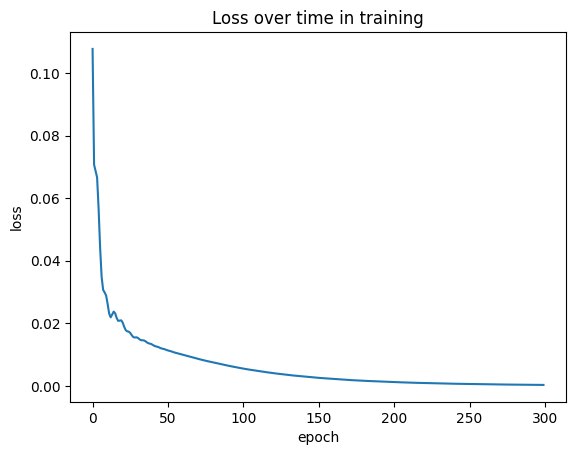

In [99]:
plt.xlabel("epoch")
plt.ylabel("loss")
plt.plot(losses)
plt.title("Loss over time in training")
plt.show()

/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/3781475295.py:121: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bias_SGD  = float(model.out.bias.numpy())
/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/3781475295.py:121: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bias_SGD  = float(model.out.bias.numpy())



Epoch 5  |  train loss: 0.0593
  risk  — SGD last layer : 0.0664
  risk  — CK descent     : 0.0309
  data insufficiency — SGD : 0.2799
  data insufficiency — CK  : 0.0000

Epoch 10  |  train loss: 0.0521
  risk  — SGD last layer : 0.0436
  risk  — CK descent     : 0.0265
  data insufficiency — SGD : 0.3033
  data insufficiency — CK  : 0.0000


/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/3781475295.py:121: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bias_SGD  = float(model.out.bias.numpy())
/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/3781475295.py:121: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bias_SGD  = float(model.out.bias.numpy())



Epoch 15  |  train loss: 0.0322
  risk  — SGD last layer : 0.0372
  risk  — CK descent     : 0.0258
  data insufficiency — SGD : 0.3277
  data insufficiency — CK  : 0.0000

Epoch 20  |  train loss: 0.0273
  risk  — SGD last layer : 0.0290
  risk  — CK descent     : 0.0276
  data insufficiency — SGD : 0.3365
  data insufficiency — CK  : 0.0000


/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/3781475295.py:121: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bias_SGD  = float(model.out.bias.numpy())
/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/3781475295.py:121: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bias_SGD  = float(model.out.bias.numpy())


...

/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/3781475295.py:121: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bias_SGD  = float(model.out.bias.numpy())
/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/3781475295.py:121: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bias_SGD  = float(model.out.bias.numpy())



Epoch 275  |  train loss: 0.0017
  risk  — SGD last layer : 0.0266
  risk  — CK descent     : 0.0273
  data insufficiency — SGD : 0.3443
  data insufficiency — CK  : 0.0000

Epoch 280  |  train loss: 0.0016
  risk  — SGD last layer : 0.0268
  risk  — CK descent     : 0.0276
  data insufficiency — SGD : 0.3443
  data insufficiency — CK  : 0.0000


/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/3781475295.py:121: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bias_SGD  = float(model.out.bias.numpy())
/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/3781475295.py:121: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bias_SGD  = float(model.out.bias.numpy())



Epoch 285  |  train loss: 0.0016
  risk  — SGD last layer : 0.0268
  risk  — CK descent     : 0.0276
  data insufficiency — SGD : 0.3443
  data insufficiency — CK  : 0.0000

Epoch 290  |  train loss: 0.0015
  risk  — SGD last layer : 0.0269
  risk  — CK descent     : 0.0276
  data insufficiency — SGD : 0.3443
  data insufficiency — CK  : 0.0000

Epoch 295  |  train loss: 0.0014
  risk  — SGD last layer : 0.0270
  risk  — CK descent     : 0.0277
  data insufficiency — SGD : 0.3443
  data insufficiency — CK  : 0.0000

Epoch 300  |  train loss: 0.0013
  risk  — SGD last layer : 0.0270
  risk  — CK descent     : 0.0277
  data insufficiency — SGD : 0.3443
  data insufficiency — CK  : 0.0000


/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/3781475295.py:121: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bias_SGD  = float(model.out.bias.numpy())
/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_11088/3781475295.py:121: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bias_SGD  = float(model.out.bias.numpy())


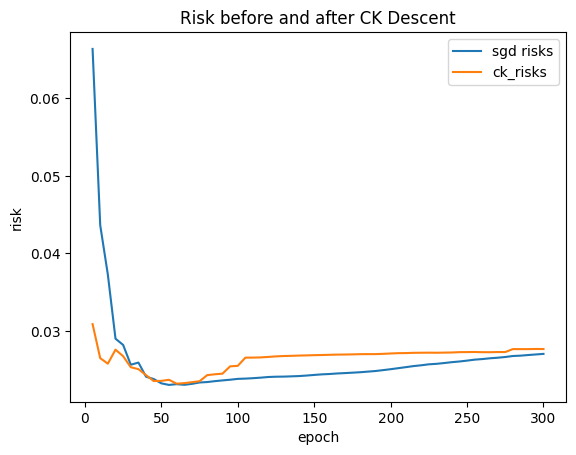

In [ ]:
N     = n_train
y_np  = y_clean.flatten()                          # 1-D numpy, full dataset

X_train_np = X_clean[:N,  :]
X_val_np   = X_clean[N:,  :]

X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_np[:N],   dtype=torch.float32).unsqueeze(1)
X_val   = torch.tensor(X_val_np,   dtype=torch.float32)

# ── model ─────────────────────────────────────────────────────────────────────
hidden_dim = 128

class GADNet(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.hidden = nn.Linear(in_dim, hidden_dim)
        self.act    = nn.ReLU()
        self.out    = nn.Linear(hidden_dim, 1)

    def features(self, x):
        return self.act(self.hidden(x))

    def forward(self, x):
        return self.out(self.features(x))

_, m       = X_clean.shape
model      = GADNet(in_dim=m, hidden_dim=hidden_dim)
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn    = nn.MSELoss()
losses     = []
sgd_risks = []
ck_risks = []
epochs = []
# ── training loop ─────────────────────────────────────────────────────────────
for epoch in range(1, n_epochs + 1):

    optimizer.zero_grad()
    preds = model(X_train)
    loss  = loss_fn(preds, y_train)
    losses.append(float(loss))
    loss.backward()
    optimizer.step()

    if epoch % 5 != 0:
        continue

    # ── extract CK feature matrices at this epoch ─────────────────────────────
    with torch.no_grad():
        M_train = model.features(X_train).numpy()   # (N,     H)
        M_val   = model.features(X_val).numpy()     # (n_val, H)

    H     = M_train.shape[1]                        # use H, not m
    n_val = M_val.shape[0]

    # ── "true" theta: fit on full width, training rows only ───────────────────
    theta_full = np.linalg.lstsq(M_train, y_np[:N], rcond=None)[0]  # (H,)

    # ── arrays to fill ────────────────────────────────────────────────────────
    xs             = np.arange(1, H)
    risk           = np.zeros(H - 1)
    norm_A         = np.zeros(H - 1)
    norm_A_theta_U = np.zeros(H - 1)
    norm_theta_U   = np.zeros(H - 1)
    norm_PN_theta  = np.zeros(H - 1)
    ranks          = np.zeros(H - 1)
    independence   = np.zeros(H - 1)

    # ── GAD loop over feature count ───────────────────────────────────────────
    for i in range(1, H):
        M_TM = M_train[:, :i]          # (N,     i)   the design matrix
        M_TU = M_train[:, i:]          # (N,     H-i) unmodeled block
        M_PM = M_val[:,   :i]          # (n_val, i)   prediction block

        theta_M = theta_full[:i]       # modeled params from "true" fit
        theta_U = theta_full[i:]       # unmodeled params from "true" fit

        M_TM_pinv = np.linalg.pinv(M_TM)
        theta_hat = M_TM_pinv @ y_np[:N]

        y_hat_train = M_TM @ theta_hat
        y_hat_val   = M_PM @ theta_hat
        y_hat_all   = np.concatenate([y_hat_train, y_hat_val])

        risk[i - 1] = np.mean((y_hat_all - y_np) ** 2)

        # aliasing
        A                    = M_TM_pinv @ M_TU
        norm_A[i - 1]        = np.linalg.norm(A, ord=2)
        norm_A_theta_U[i -1] = np.linalg.norm(A @ theta_U)

        # model insufficiency
        norm_theta_U[i - 1] = np.linalg.norm(theta_U)

        # data insufficiency — always compute, ReLU can cause early rank drops
        B  = M_TM_pinv @ M_TM
        PN = np.eye(i) - B
        norm_PN_theta[i - 1] = np.linalg.norm(PN @ theta_M)

        # diagnostics
        ranks[i - 1] = np.linalg.matrix_rank(M_TM)
        if i < H:
            new_col     = M_train[:, i:i+1]
            projection  = M_TM @ M_TM_pinv @ new_col
            residual    = new_col - projection
            independence[i - 1] = np.linalg.norm(residual) / (np.linalg.norm(new_col) + 1e-12)

    # ── CK descent: RidgeCV on frozen full-width features ─────────────────────
    ck_fit          = RidgeCV(alphas=np.logspace(-4, 2, 25)).fit(M_train, y_np[:N])
    theta_CK        = ck_fit.coef_
    bias_CK         = ck_fit.intercept_

    y_hat_CK_train  = M_train @ theta_CK + bias_CK
    y_hat_CK_val    = M_val   @ theta_CK + bias_CK
    y_hat_CK_all    = np.concatenate([y_hat_CK_train, y_hat_CK_val])
    risk_CK         = np.mean((y_hat_CK_all - y_np) ** 2)

    # ── network's own SGD last layer ──────────────────────────────────────────
    with torch.no_grad():
        theta_SGD = model.out.weight.numpy().flatten()  # (H,)
        bias_SGD  = float(model.out.bias.numpy())

    y_hat_SGD_train = M_train @ theta_SGD + bias_SGD
    y_hat_SGD_val   = M_val   @ theta_SGD + bias_SGD
    y_hat_SGD_all   = np.concatenate([y_hat_SGD_train, y_hat_SGD_val])
    risk_SGD        = np.mean((y_hat_SGD_all - y_np) ** 2)

    # ── GAD at full width for both CK and SGD ─────────────────────────────────
    # at i = H, M_TU is empty so aliasing = 0 by definition
    # only data insufficiency survives
    M_TM_pinv_full = np.linalg.pinv(M_train)
    PN_full        = np.eye(H) - M_TM_pinv_full @ M_train

    PN_theta_CK    = np.linalg.norm(PN_full @ theta_CK)
    PN_theta_SGD   = np.linalg.norm(PN_full @ theta_SGD)
    sgd_risks.append(risk_SGD)
    ck_risks.append(risk_CK)
    epochs.append(epoch)
    print(f"\nEpoch {epoch}  |  train loss: {losses[-1]:.4f}")
    print(f"  risk  — SGD last layer : {risk_SGD:.4f}")
    print(f"  risk  — CK descent     : {risk_CK:.4f}")
    print(f"  data insufficiency — SGD : {PN_theta_SGD:.4f}")
    print(f"  data insufficiency — CK  : {PN_theta_CK:.4f}")
plt.title("Risk before and after CK Descent")
plt.plot(epochs, sgd_risks, label='sgd risks')
plt.plot(epochs, ck_risks, label='ck_risks')
plt.xlabel("epoch")
plt.ylabel("risk")
plt.legend()
plt.show()